In [ ]:
# ============================================
# CUSTOMER CHURN ANALYSIS
# OBJECTIVE 1
# IDENTIFY KEY DETERMINANTS OF CUSTOMER CHURN
# ============================================

import pandas as pd

import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Regression
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Machine learning utilities
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_excel('Customer-Churn-Dataset.xls', engine='xlrd')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  object 
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCreditCard      10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Complain           10000 non-null  int64  
 10  SatisfactionScore  10000 non-null  int64  
 11  PointEarned        10000 non-null  int64  
 12  Churn              10000 non-null  int64  
dtypes: float64(2), int64(10), object(1)
memory usage: 1015.8+ KB


In [5]:
missing = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage
})

display(missing_table)

,Missing_Count,Missing_Percentage
CreditScore,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0
HasCreditCard,0,0.0
IsActiveMember,0,0.0
EstimatedSalary,0,0.0
Complain,0,0.0


In [6]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:

####Categorical variables

print(df["Gender"].value_counts(dropna=False))

Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [9]:
print(df["Churn"].value_counts(dropna=False))

Churn
0    7962
1    2038
Name: count, dtype: int64


In [11]:
###check data quality for numerical variables

numeric_variables = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "SatisfactionScore",
    "PointEarned"
]

display(df[numeric_variables].describe().T)

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
SatisfactionScore,10000.0,3.013800,1.405919,1.00,2.00,3.000,4.0000,5.00
PointEarned,10000.0,606.515100,225.924839,119.00,410.00,605.000,801.0000,1000.00


In [12]:
###check if tisina ma impossible values
###this is important for statistical modelling since we will need to do some inference

print("CreditScore range:")
print(df["CreditScore"].min(), df["CreditScore"].max())

print("\nAge range:")
print(df["Age"].min(), df["Age"].max())

print("\nTenure range:")
print(df["Tenure"].min(), df["Tenure"].max())

print("\nNumOfProducts range:")
print(df["NumOfProducts"].min(), df["NumOfProducts"].max())

print("\nSatisfactionScore range:")
print(df["SatisfactionScore"].min(), df["SatisfactionScore"].max())

print("\nPointEarned range:")
print(df["PointEarned"].min(), df["PointEarned"].max())

CreditScore range:
350 850

Age range:
18 92

Tenure range:
0 10

NumOfProducts range:
1 4

SatisfactionScore range:
1 5

PointEarned range:
119 1000


In [13]:
###let us analyse our target variable
churn_counts = df["Churn"].value_counts().sort_index()

churn_percentages = df["Churn"].value_counts(
    normalize=True
).sort_index() * 100

churn_summary = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percentages.round(2)
})

display(churn_summary)

,Count,Percentage
Churn,,
0,7962,79.62
1,2038,20.38


C:\Users\TRYMORE\AppData\Local\Temp\ipykernel_3204\3432254214.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Churned"])


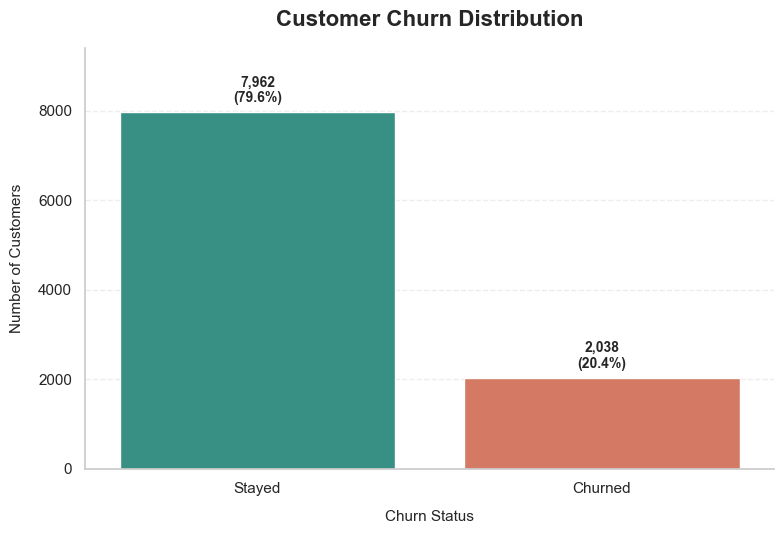

In [16]:
#####Numerical variables versus churn

##For Objective 1, we determine whether numerical characteristics differ between customers who churned and those who stayed.
churn_counts = df["Churn"].value_counts().sort_index()
total_customers = churn_counts.sum()

plt.figure(figsize=(8, 5.5))
ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    order=churn_counts.index,
    hue_order=churn_counts.index,
    palette=["#2A9D8F", "#E76F51"],
    legend=False
)

ax.set_title("Customer Churn Distribution", fontsize=16, fontweight="bold", pad=16)
ax.set_xlabel("Churn Status", fontsize=11, labelpad=10)
ax.set_ylabel("Number of Customers", fontsize=11, labelpad=10)
ax.set_xticklabels(["Stayed", "Churned"])
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for container in ax.containers:
    labels = [
        f"{int(bar.get_height()):,}\n({bar.get_height() / total_customers:.1%})"
        for bar in container
    ]
    ax.bar_label(container, labels=labels, padding=5, fontsize=10, fontweight="bold")

ax.set_ylim(0, max(churn_counts) * 1.18)
plt.tight_layout()
plt.show()

# DESCRIPTIVE STATISTICS

This section profiles the dataset and analyses every predictor against Churn, the dependent variable, using statistics appropriate to each variable type.

In [ ]:

# 1. DATASET 


print("DATASET PROFILE")
print("=" * 60)
print(f"Observations: {df.shape[0]:,}")
print(f"Variables:    {df.shape[1]:,}")
print(f"Memory used:  {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

profile = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Non_Null": df.notna().sum(),
    "Missing": df.isna().sum(),
    "Missing_%": (df.isna().mean() * 100).round(2),
    "Unique_Values": df.nunique(dropna=True),
    "Unique_%": (df.nunique(dropna=True) / len(df) * 100).round(2)
})

print("\nCOLUMN PROFILE")
display(profile)

print("DUPLICATE RECORDS")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate percentage: {df.duplicated().mean():.2%}")

DATASET PROFILE
Observations: 10,000
Variables:    13
Memory used:  1.43 MB

COLUMN PROFILE


,Data_Type,Non_Null,Missing,Missing_%,Unique_Values,Unique_%
CreditScore,int64,10000,0,0.0,460,4.60
Gender,object,10000,0,0.0,2,0.02
Age,int64,10000,0,0.0,70,0.70
Tenure,int64,10000,0,0.0,11,0.11
Balance,float64,10000,0,0.0,6382,63.82
NumOfProducts,int64,10000,0,0.0,4,0.04
HasCreditCard,int64,10000,0,0.0,2,0.02
IsActiveMember,int64,10000,0,0.0,2,0.02
EstimatedSalary,float64,10000,0,0.0,9999,99.99
Complain,int64,10000,0,0.0,2,0.02


DUPLICATE RECORDS
Duplicate rows: 0
Duplicate percentage: 0.00%


In [ ]:

# VARIABLES ANALYSED AGAINST CHURN


# Churn is the dependent variable. Numeric variables with more than 10
# distinct values are treated as continuous; low-cardinality numeric fields
# are treated as categorical or binary variables.
churn_column = "Churn"
identifier_columns = [
    column for column in ["RowNumber", "CustomerId"]
    if column in df.columns
]

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
continuous_columns = [
    column for column in numeric_columns
    if column not in identifier_columns
    and column != churn_column
    and df[column].nunique(dropna=True) > 10
]

categorical_columns = [
    column for column in df.columns
    if column not in identifier_columns
    and column != churn_column
    and (
        not pd.api.types.is_numeric_dtype(df[column])
        or df[column].nunique(dropna=True) <= 10
    )
]

churn_groups = df[churn_column].dropna().drop_duplicates().tolist()
if set(churn_groups) == {0, 1}:
    stayed_group, churned_group = 0, 1
elif set(churn_groups) >= {"No", "Yes"}:
    stayed_group, churned_group = "No", "Yes"
else:
    stayed_group, churned_group = churn_groups[0], churn_groups[-1]

stayed_label = f"Stayed ({stayed_group})"
churned_label = f"Churned ({churned_group})"
table_rows = []

for column in continuous_columns:
    overall = df[column].dropna()
    stayed = df.loc[df[churn_column] == stayed_group, column].dropna()
    churned = df.loc[df[churn_column] == churned_group, column].dropna()
    mean_difference = churned.mean() - stayed.mean()
    _, p_value = stats.ttest_ind(churned, stayed, equal_var=False, nan_policy="omit")

    table_rows.append({
        "Variable": column,
        "Type": "Continuous",
        "Level": "All values",
        "Overall": f"Mean {overall.mean():.2f}; Median {overall.median():.2f}; SD {overall.std():.2f}",
        stayed_label: f"Mean {stayed.mean():.2f}; Median {stayed.median():.2f}; SD {stayed.std():.2f}",
        churned_label: f"Mean {churned.mean():.2f}; Median {churned.median():.2f}; SD {churned.std():.2f}",
        "Association with Churn": f"Mean difference: {mean_difference:.2f}",
        "p-value": round(p_value, 4)
    })

for column in categorical_columns:
    category_series = df[column].astype("object").where(df[column].notna(), "Missing")
    contingency_table = pd.crosstab(category_series, df[churn_column])
    contingency_table = contingency_table.reindex(
        columns=churn_groups, fill_value=0
    )
    _, p_value, _, _ = stats.chi2_contingency(contingency_table)

    for level in category_series.drop_duplicates().tolist():
        level_mask = category_series == level
        overall_count = int(level_mask.sum())
        stayed_count = int((level_mask & (df[churn_column] == stayed_group)).sum())
        churned_count = int((level_mask & (df[churn_column] == churned_group)).sum())
        level_churn_rate = churned_count / (stayed_count + churned_count) * 100
        overall_percentage = overall_count / len(df) * 100
        stayed_percentage = stayed_count / (df[churn_column] == stayed_group).sum() * 100
        churned_percentage = churned_count / (df[churn_column] == churned_group).sum() * 100

        table_rows.append({
            "Variable": column,
            "Type": "Binary" if category_series.nunique() == 2 else "Categorical",
            "Level": str(level),
            "Overall": f"n={overall_count:,} ({overall_percentage:.1f}%)",
            stayed_label: f"n={stayed_count:,} ({stayed_percentage:.1f}%)",
            churned_label: f"n={churned_count:,} ({churned_percentage:.1f}%)",
            "Association with Churn": f"Level churn rate: {level_churn_rate:.1f}%",
            "p-value": round(p_value, 4)
        })

variables_against_churn = pd.DataFrame(table_rows)
variables_against_churn = variables_against_churn[
    [
        "Variable", "Type", "Level", "Overall", stayed_label,
        churned_label, "Association with Churn", "p-value"
    ]
]

print("VARIABLES ANALYSED AGAINST CHURN")
print("=" * 80)
print(f"Stayed group: {stayed_group} | Churned group: {churned_group}")
display(variables_against_churn)

variables_against_churn.to_csv(
    "variables-against-churn-results.csv",
    index=False
)

print("Continuous variables use mean, median, standard deviation, and Welch's t-test.")
print("Binary and categorical variables use counts, percentages, churn rates, and chi-square tests.")

VARIABLES ANALYSED AGAINST CHURN
Stayed group: 0 | Churned group: 1


,Variable,Type,Level,Overall,Stayed (0),Churned (1),Association with Churn,p-value
0,CreditScore,Continuous,All values,Mean 650.53; Median 652.00; SD 96.65,Mean 651.84; Median 653.00; SD 95.65,Mean 645.41; Median 646.00; SD 100.34,Mean difference: -6.42,0.0093
1,Age,Continuous,All values,Mean 38.92; Median 37.00; SD 10.49,Mean 37.41; Median 36.00; SD 10.13,Mean 44.84; Median 45.00; SD 9.76,Mean difference: 7.43,0.0000
2,Tenure,Continuous,All values,Mean 5.01; Median 5.00; SD 2.89,Mean 5.03; Median 5.00; SD 2.88,Mean 4.93; Median 5.00; SD 2.94,Mean difference: -0.10,0.1771
3,Balance,Continuous,All values,Mean 76485.89; Median 97198.54; SD 62397.41,Mean 72742.75; Median 92063.06; SD 62851.58,Mean 91109.48; Median 109344.23; SD 58346.48,Mean difference: 18366.73,0.0000
4,EstimatedSalary,Continuous,All values,Mean 100090.24; Median 100193.91; SD 57510.49,Mean 99726.85; Median 99620.35; SD 57399.96,Mean 101509.91; Median 102489.33; SD 57932.62,Mean difference: 1783.06,0.2143
5,PointEarned,Continuous,All values,Mean 606.52; Median 605.00; SD 225.92,Mean 607.04; Median 603.00; SD 226.09,Mean 604.45; Median 610.50; SD 225.32,Mean difference: -2.60,0.6429
6,Gender,Binary,Female,"n=4,543 (45.4%)","n=3,404 (42.8%)","n=1,139 (55.9%)",Level churn rate: 25.1%,0.0000
7,Gender,Binary,Male,"n=5,457 (54.6%)","n=4,558 (57.2%)",n=899 (44.1%),Level churn rate: 16.5%,0.0000
8,NumOfProducts,Categorical,1,"n=5,084 (50.8%)","n=3,675 (46.2%)","n=1,409 (69.1%)",Level churn rate: 27.7%,0.0000
9,NumOfProducts,Categorical,3,n=266 (2.7%),n=46 (0.6%),n=220 (10.8%),Level churn rate: 82.7%,0.0000


Continuous variables use mean, median, standard deviation, and Welch's t-test.
Binary and categorical variables use counts, percentages, churn rates, and chi-square tests.


# PREMIUM EXPLORATORY DATA ANALYSIS

The following visualisations examine churn from complementary perspectives: composition, categorical risk, continuous-variable separation, customer-age risk, and multivariable structure.

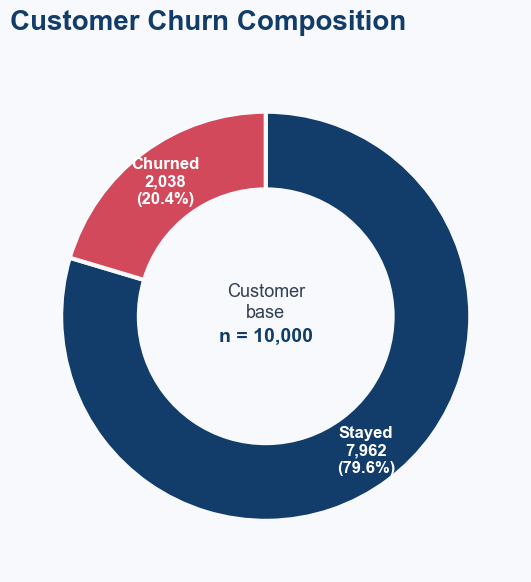

In [ ]:

# 1. CHURN COMPOSITION: EXECUTIVE VIEW


sns.set_theme(style="white", font_scale=1.05)
status_counts = df[churn_column].value_counts().reindex(
    [stayed_group, churned_group]
).dropna()
status_labels = ["Stayed", "Churned"]
status_colors = ["#123C69", "#D1495B"]

fig, axis = plt.subplots(figsize=(10, 6), facecolor="#F7F9FC")
axis.set_facecolor("#F7F9FC")
wedges, _ = axis.pie(
    status_counts,
    startangle=90,
    counterclock=False,
    colors=status_colors,
    wedgeprops={"width": 0.38, "edgecolor": "#F7F9FC", "linewidth": 3}
)

for wedge, label, count in zip(wedges, status_labels, status_counts):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x_position = np.cos(np.deg2rad(angle)) * 0.82
    y_position = np.sin(np.deg2rad(angle)) * 0.82
    axis.text(
        x_position,
        y_position,
        f"{label}\n{count:,.0f}\n({count / status_counts.sum():.1%})",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white"
    )

axis.text(0, 0.07, "Customer\nbase", ha="center", va="center", fontsize=13, color="#344054")
axis.text(0, -0.10, f"n = {status_counts.sum():,.0f}", ha="center", va="center", fontsize=14, fontweight="bold", color="#123C69")
axis.set_title("Customer Churn Composition", loc="left", fontsize=20, fontweight="bold", color="#123C69", pad=22)
axis.axis("off")
plt.tight_layout()
plt.show()

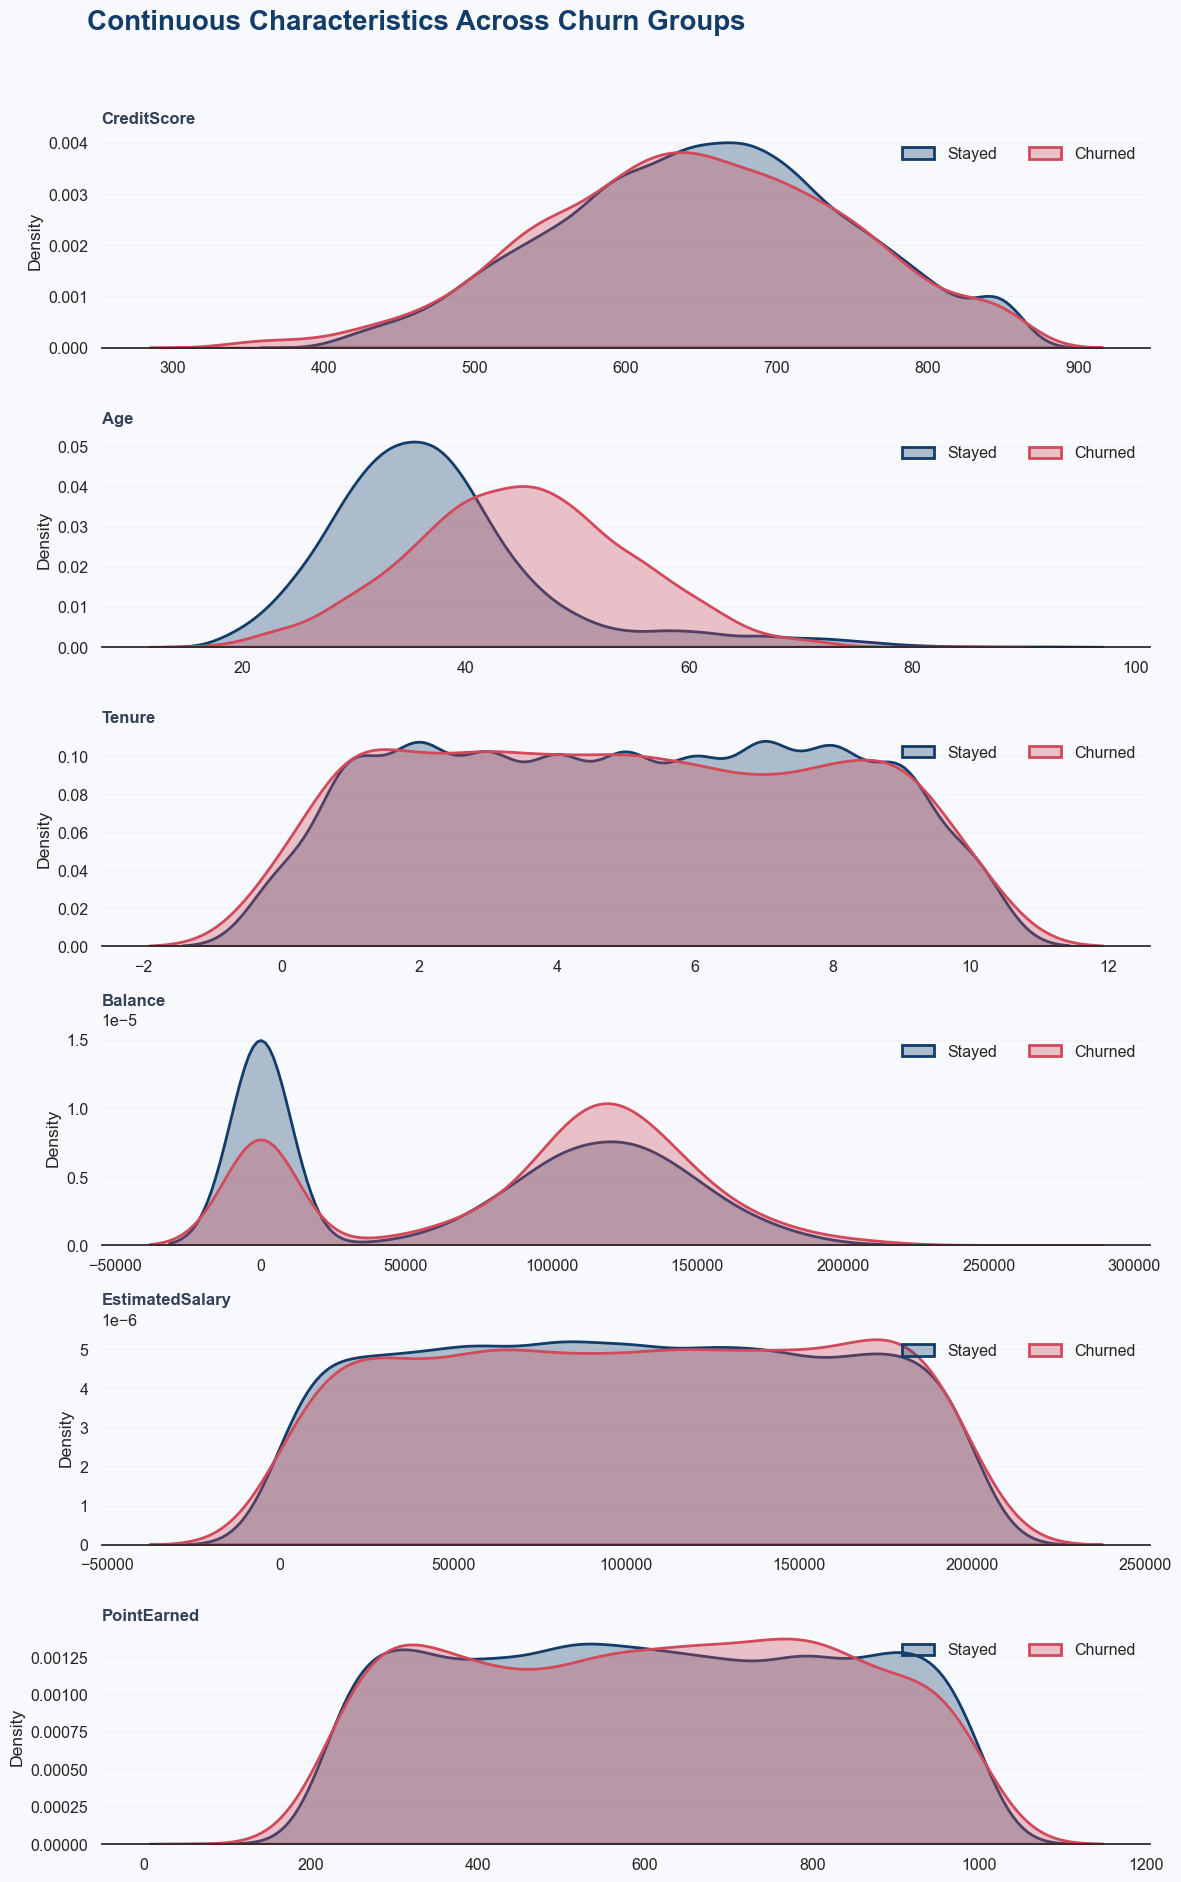

In [ ]:

# 4. CONTINUOUS DISTRIBUTIONS BY CHURN STATUS


selected_distribution_columns = continuous_columns[:min(6, len(continuous_columns))]
figure, axes = plt.subplots(
    len(selected_distribution_columns),
    1,
    figsize=(12, 3.2 * len(selected_distribution_columns)),
    facecolor="#F7F9FC"
)
axes = np.atleast_1d(axes)

for axis, column in zip(axes, selected_distribution_columns):
    axis.set_facecolor("#F7F9FC")
    sns.kdeplot(
        data=df.loc[df[churn_column] == stayed_group],
        x=column,
        fill=True,
        alpha=0.32,
        linewidth=2,
        color="#123C69",
        label="Stayed",
        ax=axis
    )
    sns.kdeplot(
        data=df.loc[df[churn_column] == churned_group],
        x=column,
        fill=True,
        alpha=0.32,
        linewidth=2,
        color="#D1495B",
        label="Churned",
        ax=axis
    )
    axis.set_title(column, loc="left", fontsize=12, fontweight="bold", color="#344054")
    axis.set_xlabel("")
    axis.set_ylabel("Density")
    axis.grid(axis="y", linestyle="--", alpha=0.22)
    axis.grid(axis="x", visible=False)
    axis.spines[["top", "right", "left"]].set_visible(False)
    axis.legend(frameon=False, ncol=2, loc="upper right")

figure.suptitle("Continuous Characteristics Across Churn Groups", x=0.08, ha="left", fontsize=20, fontweight="bold", color="#123C69")
figure.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

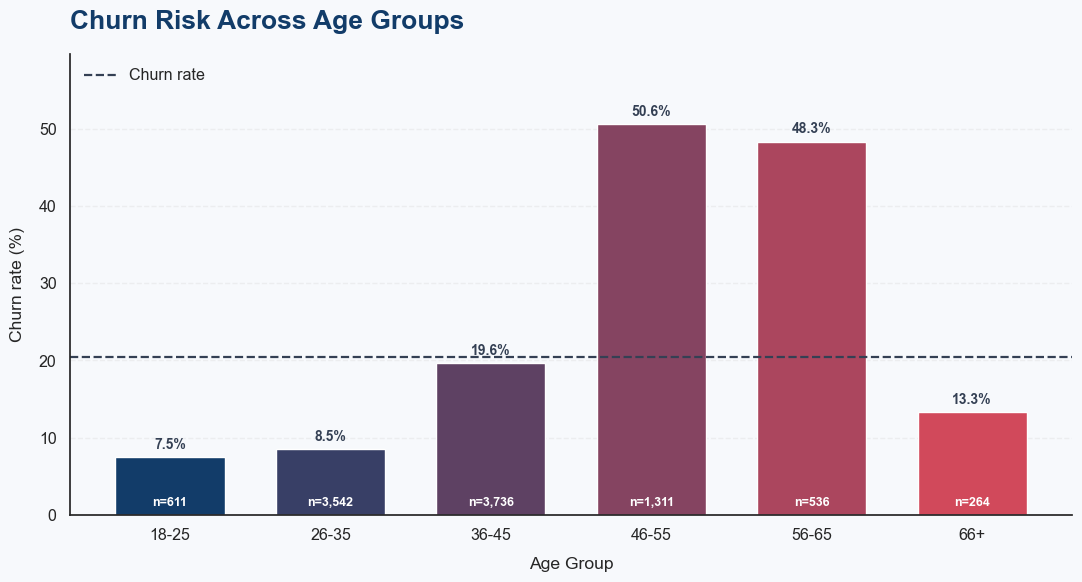

In [ ]:

# 5. AGE-group CHURN RISK PROFILE


age_column = "Age" if "Age" in df.columns else None
if age_column:
    age_bins = [0, 25, 35, 45, 55, 65, np.inf]
    age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
    age_profile = df.assign(
        Age_Band=pd.cut(df[age_column], bins=age_bins, labels=age_labels, right=True)
    ).groupby("Age_Band", observed=False)[churn_column].agg(
        Customers="count",
        Churn_Rate="mean"
    ).reset_index()
    age_profile["Churn_Rate"] *= 100

    fig, axis = plt.subplots(figsize=(11, 6), facecolor="#F7F9FC")
    axis.set_facecolor("#F7F9FC")
    bars = axis.bar(
        age_profile["Age_Band"].astype(str),
        age_profile["Churn_Rate"],
        color=sns.blend_palette(["#123C69", "#D1495B"], len(age_profile)),
        width=0.68
    )
    for bar, rate, customers in zip(bars, age_profile["Churn_Rate"], age_profile["Customers"]):
        axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.7, f"{rate:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#344054")
        axis.text(bar.get_x() + bar.get_width() / 2, 0.8, f"n={customers:,}", ha="center", va="bottom", fontsize=9, color="white", fontweight="bold")

    axis.axhline(df[churn_column].eq(churned_group).mean() * 100, color="#344054", linestyle="--", linewidth=1.6, label="Churn rate")
    axis.set_title("Churn Risk Across Age Groups", loc="left", fontsize=19, fontweight="bold", color="#123C69", pad=18)
    axis.set_xlabel("Age Group", labelpad=10)
    axis.set_ylabel("Churn rate (%)", labelpad=10)
    axis.set_ylim(0, age_profile["Churn_Rate"].max() * 1.18)
    axis.grid(axis="y", linestyle="--", alpha=0.25)
    axis.grid(axis="x", visible=False)
    axis.spines[["top", "right"]].set_visible(False)
    axis.legend(frameon=False, loc="upper left")
    plt.tight_layout()
    plt.show()

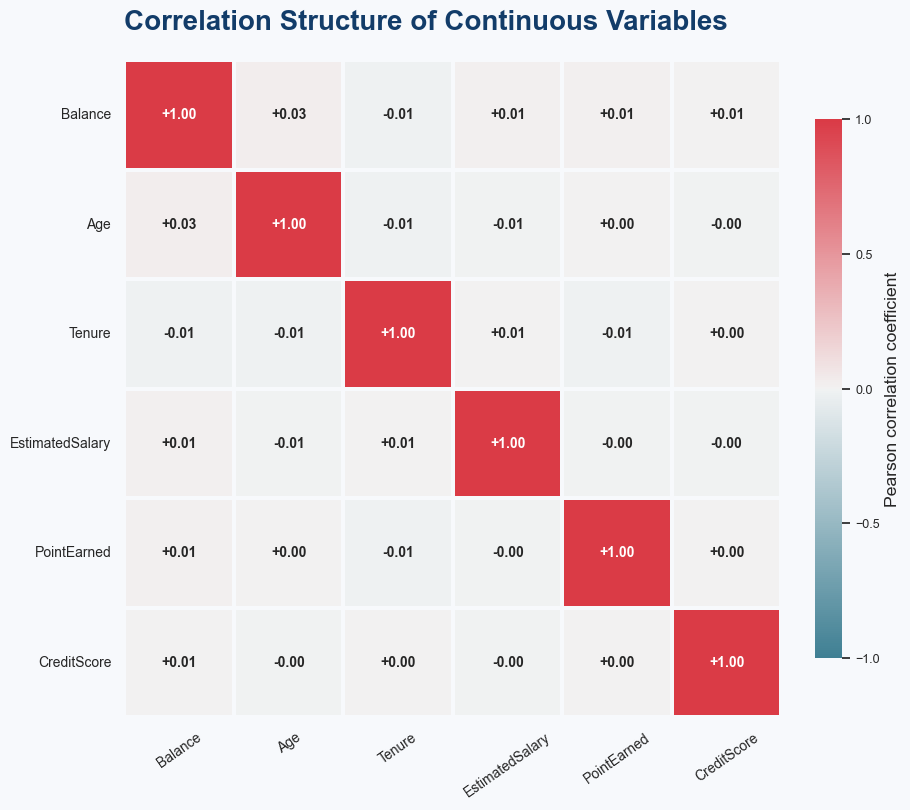

In [ ]:

# CORRELATION HEATMAP


# Correlation is calculated only among continuous predictors.
# Churn, binary variables, categorical variables, and identifiers are excluded.
continuous_correlation_data = df[continuous_columns].copy()
continuous_correlation_matrix = continuous_correlation_data.corr(method="pearson")

# Order variables by similarity in their correlation profiles for easier reading.
correlation_order = continuous_correlation_matrix.abs().sum().sort_values(ascending=False).index
continuous_correlation_matrix = continuous_correlation_matrix.loc[
    correlation_order,
    correlation_order
]

figure, axis = plt.subplots(figsize=(12, 9), facecolor="#F7F9FC")
axis.set_facecolor("#F7F9FC")

heatmap = sns.heatmap(
    continuous_correlation_matrix,
    annot=True,
    fmt="+.2f",
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1.5,
    linecolor="#F7F9FC",
    cbar_kws={
        "label": "Pearson correlation coefficient",
        "shrink": 0.82,
        "pad": 0.03
    },
    annot_kws={"fontsize": 10, "fontweight": "bold"},
    ax=axis
)

axis.set_title(
    "Correlation Structure of Continuous Variables",
    loc="left",
    fontsize=20,
    fontweight="bold",
    color="#123C69",
    pad=22
)

axis.set_xlabel("")
axis.set_ylabel("")
axis.tick_params(axis="x", rotation=35, labelsize=10)
axis.tick_params(axis="y", rotation=0, labelsize=10)

colorbar = heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=9)
colorbar.set_ticks([-1, -0.5, 0, 0.5, 1])

figure.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

# LOGISTIC REGRESSION WITH LASSO SELECTION AND INFERENCE

This section uses L1-penalized logistic regression to select predictors, followed by an unpenalized logistic regression on the selected predictors for coefficient inference. P-values and confidence intervals describe the post-selection refit and should be interpreted as exploratory.

In [42]:

# 1. PREPARE MODEL MATRIX


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_predictors = continuous_columns + categorical_columns
model_data = df[model_predictors + [churn_column]].dropna(subset=[churn_column]).copy()

# Encode the dependent variable as 0 = stayed and 1 = churned.
model_data["Churn_numeric"] = model_data[churn_column].map({
    stayed_group: 0,
    churned_group: 1
})
model_data = model_data.dropna(subset=["Churn_numeric"])

continuous_model_columns = [
    column for column in continuous_columns if column in model_data.columns
]
categorical_model_columns = [
    column for column in categorical_columns if column in model_data.columns
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse=False
    )

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])

preprocessor = ColumnTransformer([
    ("continuous", numeric_transformer, continuous_model_columns),
    ("categorical", categorical_transformer, categorical_model_columns)
])

X = model_data[model_predictors]
y = model_data["Churn_numeric"].astype(int)
X_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X_encoded = pd.DataFrame(X_encoded, columns=feature_names, index=model_data.index)

print(f"Observations used: {len(y):,}")
print(f"Encoded predictors: {X_encoded.shape[1]:,}")
print(f"Churn prevalence: {y.mean():.2%}")

Observations used: 10,000
Encoded predictors: 17
Churn prevalence: 20.38%


In [43]:

# 2. LASSO LOGISTIC REGRESSION FOR SELECTION


lasso_model = LogisticRegressionCV(
    Cs=30,
    cv=5,
    penalty="l1",
    solver="liblinear",
    scoring="roc_auc",
    max_iter=500,
    random_state=42,
    refit=True
)
lasso_model.fit(X_encoded, y)

lasso_coefficients = pd.Series(
    lasso_model.coef_[0],
    index=X_encoded.columns,
    name="LASSO_Coefficient"
)
selected_features = lasso_coefficients[lasso_coefficients.abs() > 1e-8].index.tolist()

print(f"Selected predictors: {len(selected_features)} of {X_encoded.shape[1]}")
print(f"Best inverse regularisation strength (C): {lasso_model.C_[0]:.6f}")
print("\nSelected features:")
display(lasso_coefficients.loc[selected_features].sort_values(key=np.abs, ascending=False).to_frame())

Selected predictors: 17 of 17
Best inverse regularisation strength (C): 10000.000000

Selected features:


,LASSO_Coefficient
categorical__NumOfProducts_4,15.303943
categorical__Complain_1,9.137414
categorical__NumOfProducts_3,2.142948
categorical__NumOfProducts_2,-1.412064
continuous__Age,0.940228
categorical__Gender_Male,-0.884782
categorical__IsActiveMember_1,-0.835755
categorical__SatisfactionScore_2,0.387267
categorical__SatisfactionScore_5,0.318716
continuous__Balance,0.228424


In [44]:

# 3. POST-SELECTION LOGISTIC INFERENCE


if selected_features:
    X_selected = sm.add_constant(X_encoded[selected_features], has_constant="add")
    inference_model = sm.Logit(y, X_selected).fit(disp=False, maxiter=200)
    coefficient_series = inference_model.params.drop("const", errors="ignore")
    p_value_series = inference_model.pvalues.drop("const", errors="ignore")
    confidence_intervals = inference_model.conf_int().drop("const", errors="ignore")
else:
    inference_model = None
    coefficient_series = pd.Series(dtype=float)
    p_value_series = pd.Series(dtype=float)
    confidence_intervals = pd.DataFrame(columns=[0, 1])

result_rows = []
for feature in X_encoded.columns:
    if feature.startswith("continuous__"):
        source_variable = feature.replace("continuous__", "")
        variable_type = "Continuous"
        level = "Per one standard deviation increase"
    elif feature.startswith("categorical__"):
        encoded_feature = feature.replace("categorical__", "")
        source_variable, level = encoded_feature.split("_", 1)
        variable_type = "Categorical"
    else:
        source_variable = feature
        variable_type = "Unknown"
        level = feature

    lasso_coefficient = lasso_coefficients.get(feature, 0.0)
    selected = abs(lasso_coefficient) > 1e-8
    coefficient = coefficient_series.get(feature, np.nan)
    p_value = p_value_series.get(feature, np.nan)
    confidence_interval = confidence_intervals.loc[feature].tolist() if feature in confidence_intervals.index else [np.nan, np.nan]

    if pd.notna(coefficient):
        odds_ratio = np.exp(coefficient)
        odds_ratio_lower = np.exp(confidence_interval[0])
        odds_ratio_upper = np.exp(confidence_interval[1])
        significance = "Significant" if p_value < 0.05 else "Not significant"
    else:
        odds_ratio = odds_ratio_lower = odds_ratio_upper = np.nan
        significance = "Not selected by LASSO"

    result_rows.append({
        "Variable": source_variable,
        "Variable_Type": variable_type,
        "Level_or_Unit": level,
        "LASSO_Selected": "Yes" if selected else "No",
        "LASSO_Coefficient": lasso_coefficient,
        "Inference_Coefficient": coefficient,
        "Odds_Ratio": odds_ratio,
        "OR_95%_CI_Lower": odds_ratio_lower,
        "OR_95%_CI_Upper": odds_ratio_upper,
        "p_value": p_value,
        "Significance_at_5%": significance
    })

logistic_lasso_results = pd.DataFrame(result_rows).sort_values(
    ["LASSO_Selected", "p_value"],
    ascending=[False, True],
    na_position="last"
)

logistic_lasso_results = logistic_lasso_results.round({
    "LASSO_Coefficient": 6,
    "Inference_Coefficient": 6,
    "Odds_Ratio": 4,
    "OR_95%_CI_Lower": 4,
    "OR_95%_CI_Upper": 4,
    "p_value": 6
})

display(logistic_lasso_results)
logistic_lasso_results.to_csv(
    "logistic-lasso-inference-results.csv",
    index=False
)

print("Saved: logistic-lasso-inference-results.csv")
print("Significance is based on the post-LASSO unpenalized refit at alpha = 0.05.")

c:\Users\TRYMORE\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\TRYMORE\AppData\Local\Temp\ipykernel_3204\283502188.py:40: RuntimeWarning: overflow encountered in exp
  odds_ratio_upper = np.exp(confidence_interval[1])


,Variable,Variable_Type,Level_or_Unit,LASSO_Selected,LASSO_Coefficient,Inference_Coefficient,Odds_Ratio,OR_95%_CI_Lower,OR_95%_CI_Upper,p_value,Significance_at_5%
12,Complain,Categorical,1,Yes,9.137414,9.156405,9.474932e+03,4458.7199,20134.5537,0.000000,Significant
1,Age,Continuous,Per one standard deviation increase,Yes,0.940228,0.941360,2.563500e+00,2.1786,3.0163,0.000000,Significant
7,NumOfProducts,Categorical,2,Yes,-1.412064,-1.411633,2.437000e-01,0.1811,0.3281,0.000000,Significant
6,Gender,Categorical,Male,Yes,-0.884782,-0.885062,4.127000e-01,0.3077,0.5535,0.000000,Significant
11,IsActiveMember,Categorical,1,Yes,-0.835755,-0.834613,4.340000e-01,0.3253,0.5791,0.000000,Significant
8,NumOfProducts,Categorical,3,Yes,2.142948,2.145010,8.542100e+00,2.5865,28.2115,0.000433,Significant
3,Balance,Continuous,Per one standard deviation increase,Yes,0.228424,0.228736,1.257000e+00,1.0842,1.4573,0.002430,Significant
13,SatisfactionScore,Categorical,2,Yes,0.387267,0.389462,1.476200e+00,0.9328,2.3361,0.096309,Not significant
16,SatisfactionScore,Categorical,5,Yes,0.318716,0.321432,1.379100e+00,0.8626,2.2049,0.179417,Not significant
4,EstimatedSalary,Continuous,Per one standard deviation increase,Yes,-0.096873,-0.097021,9.075000e-01,0.7855,1.0486,0.188046,Not significant


Saved: logistic-lasso-inference-results.csv
Significance is based on the post-LASSO unpenalized refit at alpha = 0.05.


# RANDOM FOREST MODEL FOR THE FIVE SELECTED PREDICTORS

This section develops and evaluates a Random Forest classifier using Gender, Age, NumOfProducts, IsActiveMember, and Complain as predictors of Churn.

In [ ]:

# 1. DEFINing THE RANDOM FOREST ANALYSIS 


from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

rf_predictors = [
    "Gender",
    "Age",
    "NumOfProducts",
    "IsActiveMember",
    "Complain"
]
rf_target = "Churn"
missing_rf_columns = [
    column for column in rf_predictors + [rf_target]
    if column not in df.columns
]
if missing_rf_columns:
    raise KeyError(f"Missing required columns: {missing_rf_columns}")

rf_data = df[rf_predictors + [rf_target]].dropna().copy()
rf_data["Churn_numeric"] = rf_data[rf_target].map({
    stayed_group: 0,
    churned_group: 1
})
rf_data = rf_data.dropna(subset=["Churn_numeric"])

rf_X = rf_data[rf_predictors]
rf_y = rf_data["Churn_numeric"].astype(int)
rf_categorical = ["Gender"]
rf_numeric = ["Age", "NumOfProducts", "IsActiveMember", "Complain"]

rf_preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), rf_categorical),
    ("numeric", "passthrough", rf_numeric)
])

rf_X_train, rf_X_test, rf_y_train, rf_y_test = train_test_split(
    rf_X,
    rf_y,
    test_size=0.20,
    stratify=rf_y,
    random_state=42
)

print(f"Analysis sample: {len(rf_data):,} customers")
print(f"Training sample: {len(rf_X_train):,} customers")
print(f"Testing sample:  {len(rf_X_test):,} customers")
print(f"Test churn prevalence: {rf_y_test.mean():.2%}")

Analysis sample: 10,000 customers
Training sample: 8,000 customers
Testing sample:  2,000 customers
Test churn prevalence: 20.40%


In [47]:

# 2. TRAIN THE RANDOM FOREST


rf_pipeline = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=600,
        max_depth=8,
        min_samples_leaf=8,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(rf_X_train, rf_y_train)
rf_test_probabilities = rf_pipeline.predict_proba(rf_X_test)[:, 1]
rf_test_predictions = (rf_test_probabilities >= 0.50).astype(int)

print("Random Forest training completed.")
print("Probability threshold used for classification: 0.50")

Random Forest training completed.
Probability threshold used for classification: 0.50


,Metric,Value
0,ROC-AUC,0.9949
1,Accuracy,0.9735
2,Precision,0.8918
3,Recall,0.9902
4,F1 score,0.9384


Classification report
              precision    recall  f1-score   support

      Stayed       1.00      0.97      0.98      1592
     Churned       0.89      0.99      0.94       408

    accuracy                           0.97      2000
   macro avg       0.94      0.98      0.96      2000
weighted avg       0.98      0.97      0.97      2000



c:\Users\TRYMORE\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


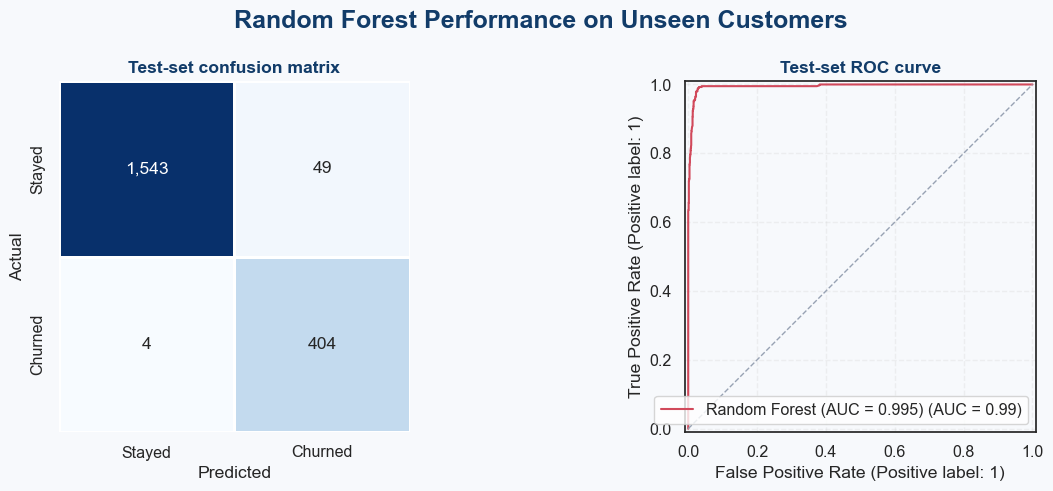

In [48]:

# 3. HOLDOUT TEST-SET PERFORMANCE


rf_test_metrics = pd.DataFrame([{
    "Metric": "ROC-AUC",
    "Value": roc_auc_score(rf_y_test, rf_test_probabilities)
}, {
    "Metric": "Accuracy",
    "Value": accuracy_score(rf_y_test, rf_test_predictions)
}, {
    "Metric": "Precision",
    "Value": precision_score(rf_y_test, rf_test_predictions, zero_division=0)
}, {
    "Metric": "Recall",
    "Value": recall_score(rf_y_test, rf_test_predictions, zero_division=0)
}, {
    "Metric": "F1 score",
    "Value": f1_score(rf_y_test, rf_test_predictions, zero_division=0)
}]).round(4)

display(rf_test_metrics)
print("Classification report")
print(classification_report(
    rf_y_test,
    rf_test_predictions,
    target_names=["Stayed", "Churned"],
    zero_division=0
))

figure, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="#F7F9FC")
for axis in axes:
    axis.set_facecolor("#F7F9FC")

confusion = confusion_matrix(rf_y_test, rf_test_predictions)
sns.heatmap(
    confusion,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=2,
    linecolor="white",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"],
    ax=axes[0]
)
axes[0].set_title("Test-set confusion matrix", fontweight="bold", color="#123C69")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

RocCurveDisplay.from_predictions(
    rf_y_test,
    rf_test_probabilities,
    name=f"Random Forest (AUC = {roc_auc_score(rf_y_test, rf_test_probabilities):.3f})",
    color="#D1495B",
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#98A2B3", linewidth=1)
axes[1].set_title("Test-set ROC curve", fontweight="bold", color="#123C69")
axes[1].grid(linestyle="--", alpha=0.25)

figure.suptitle("Random Forest Performance on Unseen Customers", fontsize=18, fontweight="bold", color="#123C69")
figure.tight_layout()
plt.show()

In [49]:

# 4. CROSS-VALIDATED PERFORMANCE STABILITY


cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    rf_pipeline,
    rf_X,
    rf_y,
    cv=cross_validation,
    scoring={
        "roc_auc": "roc_auc",
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    },
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    "Metric": ["ROC-AUC", "Accuracy", "Precision", "Recall", "F1 score"],
    "Mean": [
        cv_results["test_roc_auc"].mean(),
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean()
    ],
    "Standard_Deviation": [
        cv_results["test_roc_auc"].std(),
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std()
    ]
}).round(4)

display(cv_summary)

cv_fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "ROC_AUC": cv_results["test_roc_auc"],
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Recall": cv_results["test_recall"],
    "F1": cv_results["test_f1"]
}).round(4)
display(cv_fold_results)

print("Cross-validation assesses whether performance remains stable across different customer samples.")

,Metric,Mean,Standard_Deviation
0,ROC-AUC,0.9933,0.0018
1,Accuracy,0.9734,0.0021
2,Precision,0.8876,0.0077
3,Recall,0.9956,0.0018
4,F1 score,0.9385,0.0046


,Fold,ROC_AUC,Accuracy,Precision,Recall,F1
0,1,0.9944,0.9760,0.8965,0.9975,0.9443
1,2,0.9925,0.9720,0.8843,0.9926,0.9353
2,3,0.9943,0.9755,0.8962,0.9951,0.9431
3,4,0.9901,0.9705,0.8766,0.9951,0.9321
4,5,0.9953,0.9730,0.8845,0.9975,0.9376


Cross-validation assesses whether performance remains stable across different customer samples.


In [52]:

# 7. SAVE MODEL, METRICS AND REFERENCE TABLES


import joblib

rf_performance_results = pd.DataFrame([
    {
        "Evaluation": "Holdout test set",
        "Metric": "ROC-AUC",
        "Mean": roc_auc_score(rf_y_test, rf_test_probabilities),
        "Standard_Deviation": np.nan
    },
    {
        "Evaluation": "Holdout test set",
        "Metric": "Accuracy",
        "Mean": accuracy_score(rf_y_test, rf_test_predictions),
        "Standard_Deviation": np.nan
    },
    {
        "Evaluation": "Holdout test set",
        "Metric": "Precision",
        "Mean": precision_score(rf_y_test, rf_test_predictions, zero_division=0),
        "Standard_Deviation": np.nan
    },
    {
        "Evaluation": "Holdout test set",
        "Metric": "Recall",
        "Mean": recall_score(rf_y_test, rf_test_predictions, zero_division=0),
        "Standard_Deviation": np.nan
    },
    {
        "Evaluation": "Holdout test set",
        "Metric": "F1 score",
        "Mean": f1_score(rf_y_test, rf_test_predictions, zero_division=0),
        "Standard_Deviation": np.nan
    }
])

for metric_name, column_name in [
    ("roc_auc", "ROC-AUC"),
    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1 score")
]:
    rf_performance_results.loc[len(rf_performance_results)] = {
        "Evaluation": "5-fold cross-validation",
        "Metric": column_name,
        "Mean": cv_results[f"test_{metric_name}"].mean(),
        "Standard_Deviation": cv_results[f"test_{metric_name}"].std()
    }

rf_performance_results = rf_performance_results.round(6)
rf_performance_results.to_csv("random-forest-performance-results.csv", index=False)
importance_table.to_csv("random-forest-variable-importance.csv", index=False)
calibration_summary.to_csv("random-forest-calibration-results.csv", index=False)

random_forest_artifact = {
    "model": rf_pipeline,
    "predictors": rf_predictors,
    "target": rf_target,
    "target_mapping": {"stayed": stayed_group, "churned": churned_group},
    "threshold": 0.50
}
joblib.dump(random_forest_artifact, "random-forest-FineTuned-predictor-model.joblib")

display(rf_performance_results)
print("Saved random-forest-performance-results.csv")
print("Saved random-forest-calibration-results.csv")
print("Saved random-forest-five-predictor-model.joblib")

,Evaluation,Metric,Mean,Standard_Deviation
0,Holdout test set,ROC-AUC,0.994900,NaN
1,Holdout test set,Accuracy,0.973500,NaN
2,Holdout test set,Precision,0.891832,NaN
3,Holdout test set,Recall,0.990196,NaN
4,Holdout test set,F1 score,0.938444,NaN
5,5-fold cross-validation,ROC-AUC,0.993322,0.001843
6,5-fold cross-validation,Accuracy,0.973400,0.002083
7,5-fold cross-validation,Precision,0.887631,0.007674
8,5-fold cross-validation,Recall,0.995585,0.001834
9,5-fold cross-validation,F1 score,0.938498,0.004616


Saved random-forest-performance-results.csv
Saved random-forest-variable-importance.csv
Saved random-forest-calibration-results.csv
Saved random-forest-five-predictor-model.joblib
